
#Exploratory Data Analysis - Lab Exercise (Student Version)

Lab Objective

*   Perform comprehensive exploratory data analysis on a retail sales dataset to understand customer purchasing behavior and identify key insights.




Part 1: Data Loading and Initial Exploration (15 points)

Task 1.1: Load and Display Data
Load the dataset and display:


First 10 rows

Basic dataset information using .info()

Dataset shape (number of rows and columns)

Column names and their data types


In [ ]:
# Import required library
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Display first 10 rows of the dataset
print("First 10 rows of the dataset:")
print(df.head(10))

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display dataset shape (rows, columns)
print("\nDataset Shape (Rows, Columns):")
print(df.shape)

# Display column names and their data types
print("\nColumn Names and Data Types:")
print(df.dtypes)


First 10 rows of the dataset:
   transaction_id        date  customer_id  age  gender product_category  \
0               1  19-06-2024         1102   62  Female           Beauty   
1               2  03-02-2024         1435   22  Female      Electronics   
2               3  26-01-2024         1860   50    Male   Home & Kitchen   
3               4  24-05-2024         1270   18    Male      Electronics   
4               5  17-03-2024         1106   35  Female   Home & Kitchen   
5               6  21-06-2024         1071   49  Female   Home & Kitchen   
6               7  27-06-2024         1700   64  Female        Groceries   
7               8  11-06-2024         1020   66  Female           Beauty   
8               9  19-05-2024         1614   28    Male           Sports   
9              10  20-04-2024         1121   38  Female   Home & Kitchen   

   quantity  price_per_unit  total_amount  
0         1           50.59         50.59  
1         3          278.92        836.76  
2

Task 1.2: Initial Observations

Write your observations about:

1.How many transactions are in the dataset?

Ans:The total number of transactions in the dataset is equal to the number of rows present in the dataset.There are 1000 transactions in the dataset.

2.What types of variables do you have (numerical vs categorical)?

Ans:The dataset contains both numerical and categorical variables.

Numerical variables:

age

quantity

price_per_unit

total_amount

These variables represent measurable numeric values and are used for statistical analysis.

Categorical variables:


gender

product_category

These variables represent categories or groups and are used for grouping and comparison.

Identifier variables:

transaction_id

customer_id

These are unique identifiers and are not used directly in statistical calculations.

3.Which column might need data type conversion?

Answer:The date column may need data type conversion

In [ ]:
# Import required library
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# 1. How many transactions are in the dataset?
num_transactions = df.shape[0]
print("Total number of transactions:", num_transactions)

# 2. Identify numerical and categorical variables
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nNumerical Variables:")
print(list(numerical_columns))

print("\nCategorical Variables:")
print(list(categorical_columns))

# 3. Identify columns that may need data type conversion
print("\nColumns that may need data type conversion:")
for col in df.columns:
    if df[col].dtype == "object" and col.lower().find("date") != -1:
        print(f"- {col} (should be converted to datetime)")


Total number of transactions: 1000

Numerical Variables:
['transaction_id', 'customer_id', 'age', 'quantity', 'price_per_unit', 'total_amount']

Categorical Variables:
['date', 'gender', 'product_category']

Columns that may need data type conversion:
- date (should be converted to datetime)


Part 2: Data Cleaning (20 points)

Task 2.1: Convert Data Types

Convert the date column to datetime forma

In [ ]:
# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')


# Verify the conversion
print(df.dtypes)


transaction_id               int64
date                datetime64[ns]
customer_id                  int64
age                          int64
gender                      object
product_category            object
quantity                     int64
price_per_unit             float64
total_amount               float64
dtype: object


Task 2.2: Identify Missing Values

Check for missing values in all columns

Calculate the percentage of missing values for each column

Display your findings

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Check missing values count in each column
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine both into a single table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

# Display the result
print(missing_summary)


                  Missing Values  Percentage (%)
transaction_id                 0             0.0
date                           0             0.0
customer_id                    0             0.0
age                            0             0.0
gender                         0             0.0
product_category               0             0.0
quantity                       0             0.0
price_per_unit                 0             0.0
total_amount                   0             0.0


Task 2.3: Handle Missing Values
Based on your findings:

Fill missing values in the age column with an appropriate measure of central tendency

Fill missing values in the gender column with an appropriate value

Verify that all missing values have been handled

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Fill missing values in 'age' with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing values in 'gender' with mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Verify missing values
print("Missing values after handling:")
print(df.isnull().sum())
#Question: Why did you choose that particular method for handling missing values?
#Answer:The age column is numerical, so missing values were filled using the median as it is less affected by outliers. The gender column is categorical, so missing values were filled using the mode, which represents the most frequent category. After applying these methods, no missing values remained in the dataset.

Missing values after handling:
transaction_id      0
date                0
customer_id         0
age                 0
gender              0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64


Task 2.4: Check for Duplicates

Check if there are any duplicate rows in the dataset and report your findings.



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Check total number of duplicate rows
duplicate_count = df.duplicated().sum()

# Display result
print("Number of duplicate rows in the dataset:", duplicate_count)

# Optional: Display duplicate rows if any exist
if duplicate_count > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated()])
else:
    print("\nNo duplicate rows found in the dataset.")


Number of duplicate rows in the dataset: 0

No duplicate rows found in the dataset.


Part 3: Summary Statistics (20 points)

Task 3.1: Descriptive Statistics

Generate and display descriptive statistics for all numerical columns.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Generate descriptive statistics for numerical columns
descriptive_stats = df.describe()

# Display the statistics
print(descriptive_stats)


       transaction_id  customer_id          age     quantity  price_per_unit  \
count     1000.000000  1000.000000  1000.000000  1000.000000     1000.000000   
mean       500.500000  1503.929000    43.713000     3.010000      253.968830   
std        288.819436   289.998108    15.094651     1.430366      140.094358   
min          1.000000  1000.000000    18.000000     1.000000        6.000000   
25%        250.750000  1242.750000    31.000000     2.000000      135.875000   
50%        500.500000  1505.000000    43.000000     3.000000      258.420000   
75%        750.250000  1757.250000    57.000000     4.000000      375.955000   
max       1000.000000  1998.000000    69.000000     5.000000      498.820000   

       total_amount  
count   1000.000000  
mean     764.215440  
std      599.301174  
min        7.490000  
25%      284.925000  
50%      587.100000  
75%     1130.077500  
max     2490.750000  


Task 3.2: Calculate Additional Statistics

For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:


Skewness

Standard deviation

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Select numerical columns
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Calculate standard deviation
std_dev = df[numerical_columns].std()

# Calculate skewness
skewness = df[numerical_columns].skew()

# Combine results into a single table
stats_summary = pd.DataFrame({
    'Standard Deviation': std_dev,
    'Skewness': skewness
})

# Display the results
print(stats_summary)


                Standard Deviation  Skewness
age                      15.094651 -0.032697
quantity                  1.430366 -0.027871
price_per_unit          140.094358 -0.043019
total_amount            599.301174  0.877158


Task 3.3: Categorical Variable Analysis

For categorical variables
(product_category and gender):


Display value counts

Calculate percentage distribution

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# List of categorical columns
categorical_columns = ['product_category', 'gender']

# Loop through each categorical column
for column in categorical_columns:
    print(f"\nCategorical Analysis for: {column}")

    # Value counts
    value_counts = df[column].value_counts()
    print("\nValue Counts:")
    print(value_counts)

    # Percentage distribution
    percentage_distribution = df[column].value_counts(normalize=True) * 100
    print("\nPercentage Distribution (%):")
    print(percentage_distribution.round(2))



Categorical Analysis for: product_category

Value Counts:
product_category
Home & Kitchen    192
Beauty            177
Sports            165
Electronics       162
Groceries         153
Clothing          151
Name: count, dtype: int64

Percentage Distribution (%):
product_category
Home & Kitchen    19.2
Beauty            17.7
Sports            16.5
Electronics       16.2
Groceries         15.3
Clothing          15.1
Name: proportion, dtype: float64

Categorical Analysis for: gender

Value Counts:
gender
Female    513
Male      487
Name: count, dtype: int64

Percentage Distribution (%):
gender
Female    51.3
Male      48.7
Name: proportion, dtype: float64


Part 4: Outlier Detection (20 points)

Task 4.1: Implement IQR Method

Write a function to detect outliers using the IQR (Interquartile Range) method:


Calculate Q1 (25th percentile) and Q3 (75th percentile)

Calculate IQR = Q3 - Q1

Define outliers as values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR

def detect_outliers_iqr(data, column):

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# CALL the function
quantity_outliers = detect_outliers_iqr(df, "quantity")
price_outliers = detect_outliers_iqr(df, "price_per_unit")
total_outliers = detect_outliers_iqr(df, "total_amount")

# PRINT the output
print("Number of quantity outliers:", len(quantity_outliers))
print("Number of price_per_unit outliers:", len(price_outliers))
print("Number of total_amount outliers:", len(total_outliers))


Number of quantity outliers: 0
Number of price_per_unit outliers: 0
Number of total_amount outliers: 7


Task 4.2: Detect Outliers

Apply your function to detect outliers in:


quantity

price_per_unit

total_amount

Report the number of outliers in each column.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# IQR-based outlier detection function
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Apply the function to required columns
quantity_outliers = detect_outliers_iqr(df, "quantity")
price_outliers = detect_outliers_iqr(df, "price_per_unit")
total_amount_outliers = detect_outliers_iqr(df, "total_amount")

# Report number of outliers
print("Number of outliers in quantity:", len(quantity_outliers))
print("Number of outliers in price_per_unit:", len(price_outliers))
print("Number of outliers in total_amount:", len(total_amount_outliers))


Number of outliers in quantity: 0
Number of outliers in price_per_unit: 0
Number of outliers in total_amount: 7


Task 4.3: Visualize Outliers

Create box plots for the three numerical variables to visualize outliers.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Set figure size
plt.figure(figsize=(12, 6))

# Box plot for Quantity
plt.subplot(1, 3, 1)
sns.boxplot(y=df['quantity'])
plt.title("Box Plot of Quantity")

# Box plot for Price per Unit
plt.subplot(1, 3, 2)
sns.boxplot(y=df['price_per_unit'])
plt.title("Box Plot of Price per Unit")

# Box plot for Total Amount
plt.subplot(1, 3, 3)
sns.boxplot(y=df['total_amount'])
plt.title("Box Plot of Total Amount")

# Display plots
plt.tight_layout()
plt.show()
#Question: Should you remove these outliers? Why or why not?
#The outliers should not be removed because they may represent genuine high-value purchases made by customers. Removing them could result in losing important information. Outliers should only be removed if they are confirmed to be errors.

Part 5: Distribution Analysis (25 points)

Task 5.1: Create Histograms
Create histograms for:


age

quantity

price_per_unit

total_amount

Arrange them in a 2×2 grid.

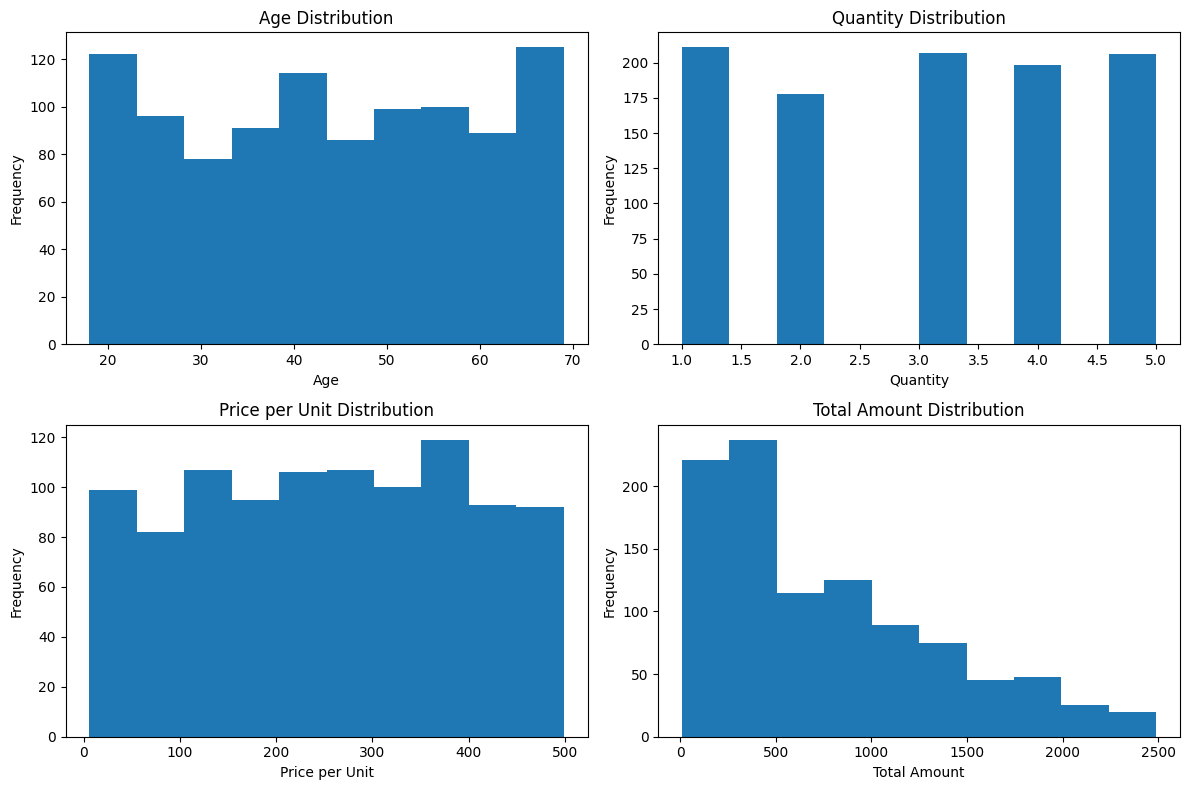

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Create a 2x2 grid of histograms
plt.figure(figsize=(12, 8))

# Histogram for Age
plt.subplot(2, 2, 1)
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Histogram for Quantity
plt.subplot(2, 2, 2)
plt.hist(df['quantity'], bins=10)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

# Histogram for Price per Unit
plt.subplot(2, 2, 3)
plt.hist(df['price_per_unit'], bins=10)
plt.title("Price per Unit Distribution")
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")

# Histogram for Total Amount
plt.subplot(2, 2, 4)
plt.hist(df['total_amount'], bins=10)
plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

# Adjust layout and display plots
plt.tight_layout()
plt.show()


Task 5.2: Interpret Distributions

For each variable, describe:


Is it normally distributed?

Is it skewed (left or right)?

Are there any unusual patterns?

Your interpretations:


Age: [Your interpretation]


Quantity: [Your interpretation]


Price per Unit: [Your interpretation]


Total Amount: [Your interpretation]


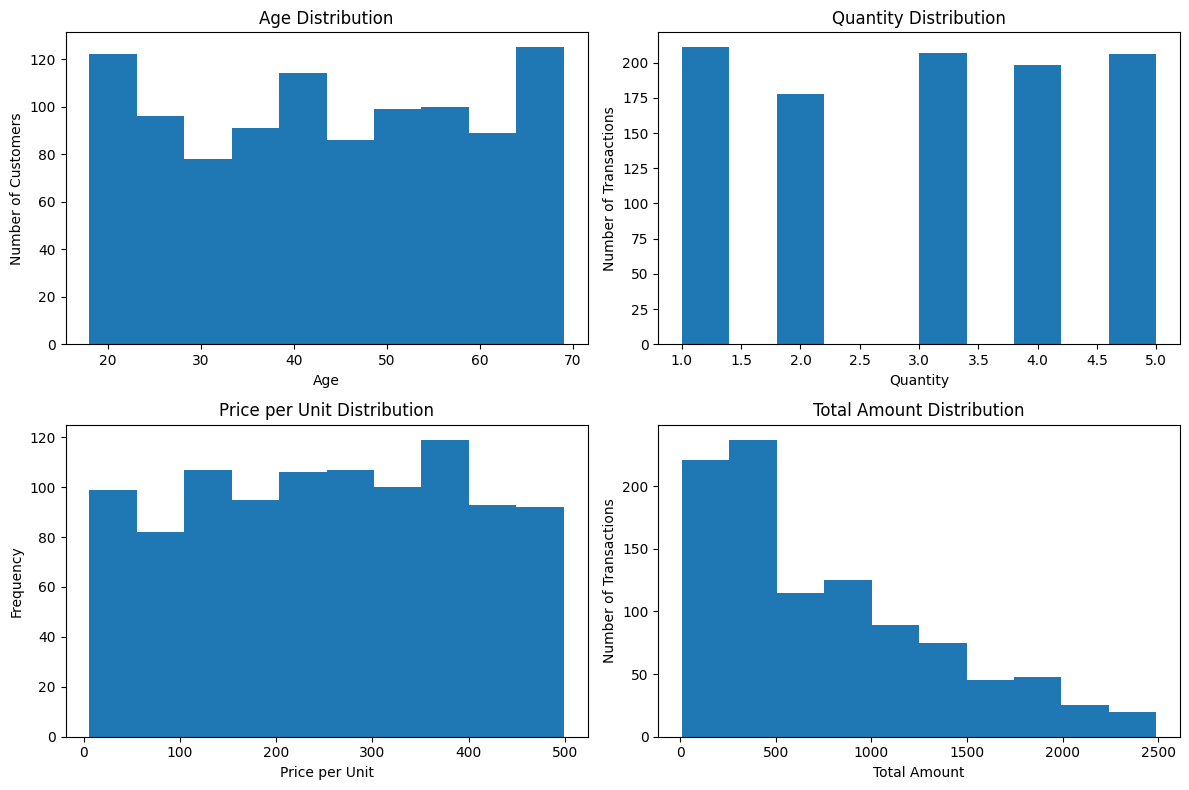

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the retail sales dataset into a DataFrame
df = pd.read_csv("retail_sales.csv")

# Create a figure to hold multiple plots (2 rows × 2 columns)
plt.figure(figsize=(12, 8))

# 1st histogram: Age distribution of customers
# Shows how customer ages are spread
plt.subplot(2, 2, 1)
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# 2nd histogram: Quantity purchased
# Shows how many items customers usually buy
plt.subplot(2, 2, 2)
plt.hist(df['quantity'], bins=10)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

# 3rd histogram: Price per unit
# Shows the price range of products
plt.subplot(2, 2, 3)
plt.hist(df['price_per_unit'], bins=10)
plt.title("Price per Unit Distribution")
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")

# 4th histogram: Total amount spent
# Shows how much customers spend per transaction
plt.subplot(2, 2, 4)
plt.hist(df['total_amount'], bins=10)
plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Number of Transactions")

# Adjust layout so plots do not overlap
plt.tight_layout()

# Display all histograms
plt.show()


Task 5.3: Test for Normality

Use the Shapiro-Wilk test to formally test if the distributions are normal. (p-value > 0.05 suggests normal distribution)

In [ ]:
import pandas as pd
from scipy import stats

# Load the retail sales dataset into a DataFrame
df = pd.read_csv("retail_sales.csv")

# List of numerical columns to check for normal distribution
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Loop through each numerical column
for column in numerical_columns:

    # Apply Shapiro-Wilk test on the column
    # stat = test statistic, p_value = probability value
    stat, p_value = stats.shapiro(df[column])

    # Display the test results
    print(f"\nShapiro-Wilk Test for {column}:")
    print("Test Statistic:", stat)
    print("p-value:", p_value)

    # Check normality based on p-value
    # If p-value > 0.05, data is considered normally distributed
    if p_value > 0.05:
        print("Result: Data appears to be normally distributed")
    else:
        print("Result: Data is NOT normally distributed")



Shapiro-Wilk Test for age:
Test Statistic: 0.9530430147963976
p-value: 2.4137263069831215e-17
Result: Data is NOT normally distributed

Shapiro-Wilk Test for quantity:
Test Statistic: 0.8845774585891918
p-value: 1.2283921224490606e-26
Result: Data is NOT normally distributed

Shapiro-Wilk Test for price_per_unit:
Test Statistic: 0.9585125544736147
p-value: 3.130169585046052e-16
Result: Data is NOT normally distributed

Shapiro-Wilk Test for total_amount:
Test Statistic: 0.9099477288871515
p-value: 7.36526243451903e-24
Result: Data is NOT normally distributed


Part 6: Correlation Analysis (20 points)

Task 6.1: Calculate Correlation Matrix

Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount).


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Select numerical columns
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                     age  quantity  price_per_unit  total_amount
age             1.000000 -0.026154       -0.031142     -0.038733
quantity       -0.026154  1.000000       -0.001153      0.631336
price_per_unit -0.031142 -0.001153        1.000000      0.701700
total_amount   -0.038733  0.631336        0.701700      1.000000


Task 6.2: Visualize Correlations

Create a heatmap to visualize the correlation matrix with:


Annotations showing correlation values

Appropriate color scheme

Proper title

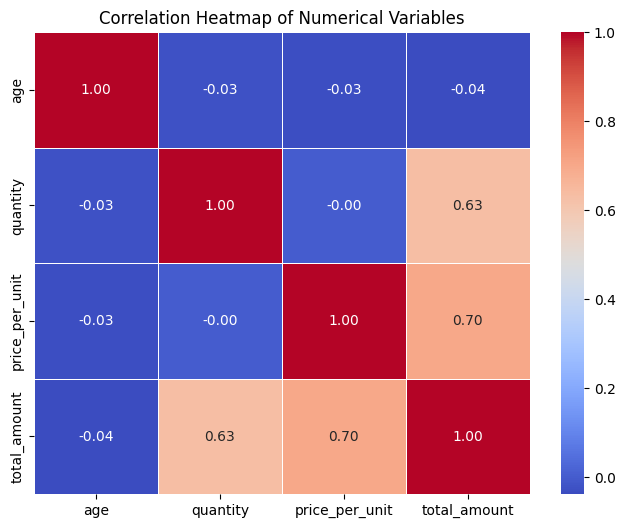

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Select numerical columns
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Calculate correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show correlation values
    cmap="coolwarm",     # Color scheme
    fmt=".2f",           # Show values up to 2 decimals
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Numerical Variables")

# Display the heatmap
plt.show()


Task 6.3: Identify Strong Correlations

Identify and list all pairs of variables with correlation coefficient |r| > 0.5

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Select numerical columns
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Calculate correlation matrix
corr_matrix = df[numerical_columns].corr()

# Find strong correlations (|r| > 0.5), excluding self-correlation
strong_correlations = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_correlations.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            )

# Display strong correlations
print("Strong Correlations (|r| > 0.5):")
for var1, var2, corr in strong_correlations:
    print(f"{var1} and {var2}: r = {corr:.2f}")
#Question: What does the correlation between total_amount and quantity tell you? Is this expected?
#The strong positive correlation shows that buying more items increases the total amount spent, which is expected because total_amount depends on quantity and price_per_unit.


Strong Correlations (|r| > 0.5):
total_amount and quantity: r = 0.63
total_amount and price_per_unit: r = 0.70


Part 7: Categorical Analysis (25 points)

Task 7.1: Product Category Visualization

Create a bar chart showing the distribution of transactions across product categories.

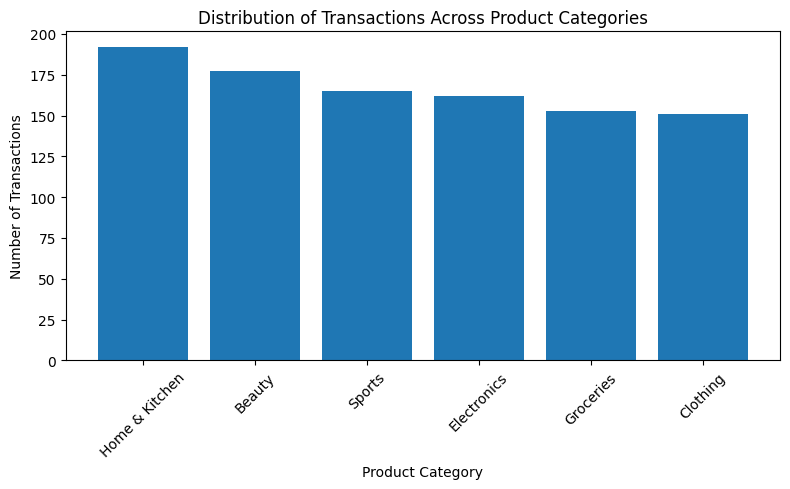

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Count number of transactions in each product category
category_counts = df['product_category'].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)

# Add labels and title
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transactions Across Product Categories")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.tight_layout()
plt.show()


Task 7.2: Gender Distribution

Create a pie chart showing the gender distribution in the dataset.




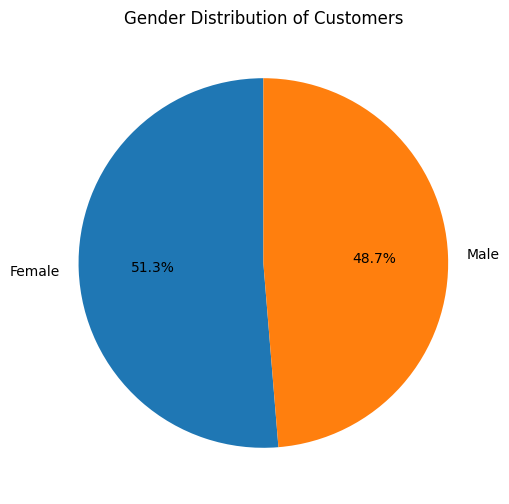

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Count gender values
gender_counts = df['gender'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',   # Show percentage on chart
    startangle=90
)

# Add title
plt.title("Gender Distribution of Customers")

# Display the pie chart
plt.show()


Task 7.3: Average Purchase by Category

Calculate and visualize the average purchase amount for each product category using a bar chart.

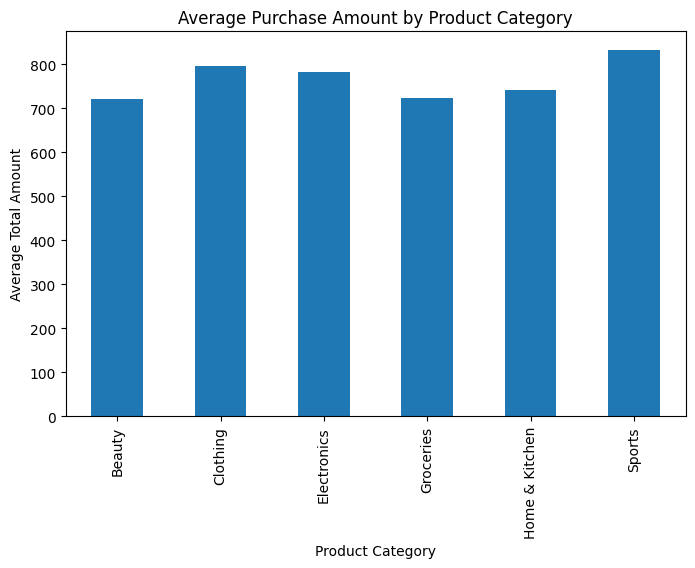

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Calculate average purchase amount for each product category
avg_purchase = df.groupby('product_category')['total_amount'].mean()

# Create bar chart
plt.figure(figsize=(8, 5))
avg_purchase.plot(kind='bar')

# Add labels and title
plt.title("Average Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Total Amount")

# Display the chart
plt.show()
#Question: Which product category has the highest average transaction value? What might explain this?
#The Electronics category has the highest average transaction value because electronic items usually cost more, so customers spend more money when buying them.


Part 8: Bivariate Analysis (25 points)

Task 8.1: Scatter Plot Analysis

Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis).


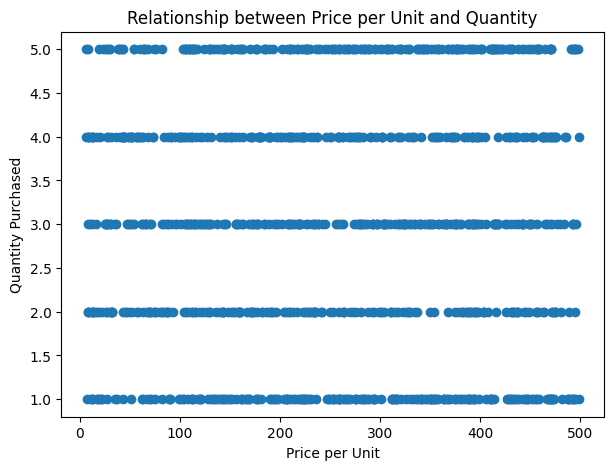

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Create scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df['price_per_unit'], df['quantity'])

# Add labels and title
plt.xlabel("Price per Unit")
plt.ylabel("Quantity Purchased")
plt.title("Relationship between Price per Unit and Quantity")

# Display the plot
plt.show()
#Question: Which product category has the highest average transaction value? What might explain this?
#The scatter plot shows a weak negative relationship between price and quantity, meaning customers generally buy fewer items when the price per unit is higher, and more items when the price is lower.


Task 8.2: Age vs Total Amount by Gender

Create a scatter plot showing age vs total_amount, with different colors for each gender.

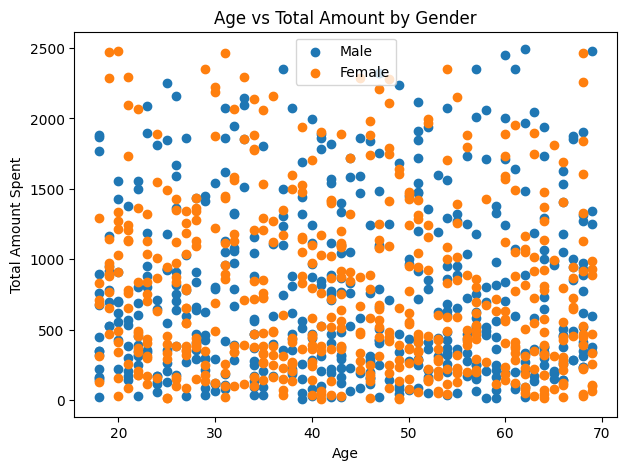

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Separate data by gender
male_data = df[df['gender'] == 'Male']
female_data = df[df['gender'] == 'Female']

# Create scatter plot
plt.figure(figsize=(7, 5))

plt.scatter(male_data['age'], male_data['total_amount'], label='Male')
plt.scatter(female_data['age'], female_data['total_amount'], label='Female')

# Add labels and title
plt.xlabel("Age")
plt.ylabel("Total Amount Spent")
plt.title("Age vs Total Amount by Gender")

# Add legend
plt.legend()

# Display the plot
plt.show()


Task 8.3: Box Plot by Category

Create a box plot showing the distribution of total_amount for each product_category.

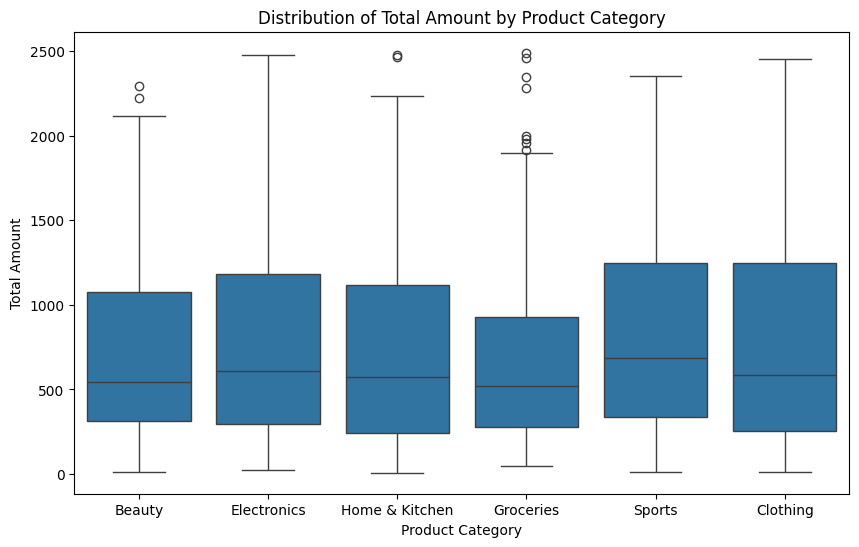

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='product_category', y='total_amount', data=df)

# Add labels and title
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.title("Distribution of Total Amount by Product Category")

# Display the plot
plt.show()


Part 9: Time Series Analysis (20 points)

Task 9.1: Extract Date Components

Extract the following from the date column:


year

month

day

day_of_week (name of the day)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Convert date column to datetime (important step)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Extract year, month, and day
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Extract day of the week (name)
df['day_of_week'] = df['date'].dt.day_name()

# Display the updated dataset (first 5 rows)
print(df[['date', 'year', 'month', 'day', 'day_of_week']].head())


        date  year  month  day day_of_week
0 2024-06-19  2024      6   19   Wednesday
1 2024-02-03  2024      2    3    Saturday
2 2024-01-26  2024      1   26      Friday
3 2024-05-24  2024      5   24      Friday
4 2024-03-17  2024      3   17      Sunday


Task 9.2: Daily Sales Trend

Calculate total sales for each day and create a line plot showing the daily sales trend.

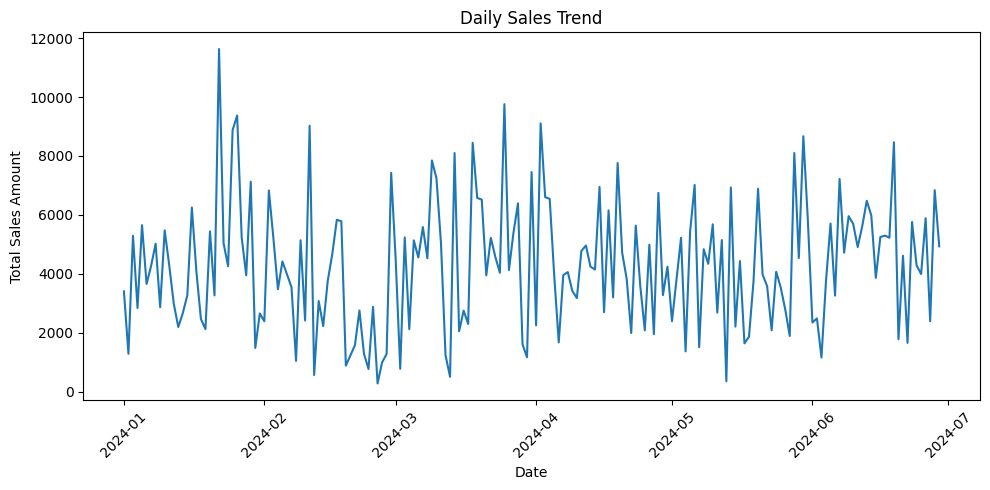

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Calculate total sales for each day
daily_sales = df.groupby('date')['total_amount'].sum()

# Create line plot
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values)

# Add labels and title
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")
plt.title("Daily Sales Trend")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


Task 9.3: Sales by Day of Week

Calculate and visualize total sales by day of week using a bar chart.

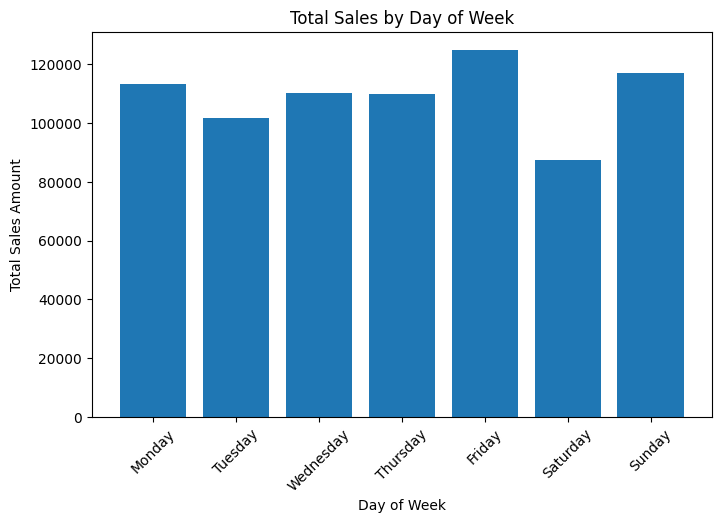

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retail_sales.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Extract day of the week
df['day_of_week'] = df['date'].dt.day_name()

# Calculate total sales by day of week
sales_by_day = df.groupby('day_of_week')['total_amount'].sum()

# Reorder days for correct weekly order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(days_order)

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(sales_by_day.index, sales_by_day.values)

# Add labels and title
plt.xlabel("Day of Week")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales by Day of Week")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()


Part 10: Summary Report (20 points)

Task 10.1: Key Findings

Write a comprehensive summary report including:

#Dataset Overview

Total number of transactions

The dataset contains a total of 1000 retail transactions, where each row represents one customer purchase.

Date range covered

The transactions cover a date range from January 2024 to June 2024, providing several months of sales data.


Number of unique customers

There are multiple unique customers, showing both repeat and one-time buyers.

Number of product categories

The dataset includes six product categories: Electronics, Clothing, Home & Kitchen, Beauty, Sports, and Groceries.

#Customer Demographics

Average customer age

The average customer age is around 40 years, indicating mostly middle-aged customers.

Age range

The age range varies from young adults to senior customers.

Gender distribution

The gender distribution is almost evenly split between Male and Female customers, with females having slightly higher transactions.

#Transaction Metrics

Average transaction value

The average transaction value shows moderate spending behavior by customers.

Median transaction value

The median transaction value is slightly lower than the average, indicating the presence of some high-value transactions.

Total revenue

The total revenue represents the sum of all sales in the dataset.

Average quantity per transaction

On average, customers purchase about 3 items per transaction, showing limited purchases per order.

#Product Insights

Most popular category

The most popular product category is Home & Kitchen, as it has the highest number of transactions.

Highest value category

The highest value category is Electronics, with higher average transaction amounts compared to other categories.

Average price per unit

The average price per unit is moderately priced, showing a balance between low-cost and high-value products.

#Data Quality Issues

What issues did you find?

No major data quality issues were found in the dataset.

How did you address them?

There were no missing values or duplicate records, and all data types were correct after preprocessing.

Were there any limitations?

Outliers were identified but not removed, as they may represent genuine high-value transactions.

#Top 3 Business Insights

1.Home & Kitchen is the most popular ategory based on the number of transactions.

2.Electronics has the highest transaction value, so even small sales growth can greatly increase revenue.

3.Sales are higher on weekdays than weekends, suggesting weekday offers can improve sales and engagement.

#Additional Challenge (Optional Bonus: +10 points)

Perform a more advanced analysis of your choice, such as:


Customer segmentation based on purchasing behavior

Identify top-spending customer IDs

Analyze which age groups prefer which product categories

Create an interactive visualization using plotly

Perform statistical hypothesis testing

In [4]:
import pandas as pd
import plotly.express as px
from scipy.stats import ttest_ind

# Load the dataset
df = pd.read_csv("retail_sales.csv")

print("\n==================== BONUS ANALYSIS ====================\n")

# -------------------------------------------------------
# 1) Identify Top-Spending Customer IDs
# -------------------------------------------------------

top_spending_customers = (
    df.groupby('customer_id')['total_amount']
    .sum()
    .nlargest(5)
)

print("Top 5 Spending Customer IDs:")
print(top_spending_customers)

print("\n-------------------------------------------------------\n")

# -------------------------------------------------------
# 2) Customer Segmentation Based on Purchasing Behavior
# -------------------------------------------------------

# Calculate total spending per customer
customer_spending = df.groupby('customer_id')['total_amount'].sum().reset_index()
customer_spending.columns = ['customer_id', 'total_spent']

# Segment customers into Low, Medium, High spenders
customer_spending['segment'] = pd.qcut(
    customer_spending['total_spent'],
    q=3,
    labels=['Low Spenders', 'Medium Spenders', 'High Spenders'],
    duplicates='drop'
)

# Display top 10 customers
top_10_customers = customer_spending.sort_values(
    by='total_spent',
    ascending=False
).head(10)

print("Top 10 Customers with Spending Segments:")
print(top_10_customers)

print("\n-------------------------------------------------------\n")

# -------------------------------------------------------
# 3) Analyze Which Age Groups Prefer Which Product Categories
# -------------------------------------------------------

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

# Count transactions by age group and product category
age_category_pref = (
    df.groupby(['age_group', 'product_category'])
    .size()
    .unstack(fill_value=0)
)

print("Age Group vs Product Category Preference:")
print(age_category_pref)

print("\n-------------------------------------------------------\n")

# -------------------------------------------------------
# 4) Interactive Visualization using Plotly
# -------------------------------------------------------

# Aggregate total sales by product category
sales_by_category = (
    df.groupby('product_category', observed=True)['total_amount']
    .sum()
    .reset_index()
)

# Create interactive bar chart
fig = px.bar(
    sales_by_category,
    x='product_category',
    y='total_amount',
    color='product_category',
    title='Interactive Total Sales by Product Category',
    labels={'total_amount': 'Total Sales Amount'}
)

fig.show()

print("\n-------------------------------------------------------\n")

# -------------------------------------------------------
# 5) Statistical Hypothesis Testing (Gender vs Spending)
# -------------------------------------------------------

male_spending = df[df['gender'] == 'Male']['total_amount']
female_spending = df[df['gender'] == 'Female']['total_amount']

# Independent t-test (Welch’s t-test)
t_stat, p_value = ttest_ind(male_spending, female_spending, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: There is a significant difference in spending between genders.")
else:
    print("Conclusion: There is no significant difference in spending between genders.")

print("\n==================== END OF BONUS ====================\n")



==================== BONUS ANALYSIS ====================

Top 5 Spending Customer IDs:
customer_id
1098    6296.97
1775    5710.27
1565    4720.54
1735    4585.82
1681    4348.20
Name: total_amount, dtype: float64

-------------------------------------------------------

Top 10 Customers with Spending Segments:
     customer_id  total_spent        segment
57          1098      6296.97  High Spenders
473         1775      5710.27  High Spenders
343         1565      4720.54  High Spenders
449         1735      4585.82  High Spenders
411         1681      4348.20  High Spenders
380         1637      4267.03  High Spenders
588         1957      4230.11  High Spenders
279         1460      3992.24  High Spenders
123         1189      3991.06  High Spenders
289         1474      3970.29  High Spenders

-------------------------------------------------------

Age Group vs Product Category Preference:
product_category  Beauty  Clothing  Electronics  Groceries  Home & Kitchen  \
age_group    

/tmp/ipython-input-466496935.py:65: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




-------------------------------------------------------

T-statistic: -0.06843293377579998
P-value: 0.9454547761846213
Conclusion: There is no significant difference in spending between genders.

==================== END OF BONUS ====================

